## 기본세팅

In [1]:
import platform
import matplotlib.pyplot as plt

# 한글 폰트 설정
def set_matplotlib_font():
    system = platform.system()
    if system == "Windows":
        plt.rc('font', family='Malgun Gothic')
    elif system == "Darwin":  # macOS
        plt.rc('font', family='AppleGothic')
    elif system == "Linux":
        plt.rc('font', family='NanumGothic')
    else:
        print("Unknown system. Please set font manually.")
    plt.rcParams['axes.unicode_minus'] = False
set_matplotlib_font()

# 전체+시즌별

## 전체

In [2]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 전처리
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])

# 2. Prophet 학습용 데이터 준비
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 주차 예측
m = Prophet(
    changepoint_prior_scale=0.1,
    changepoint_range=0.9,
    seasonality_prior_scale=10,
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

future = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0).astype(int)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산 (T1, T*, T2)
T_star_idx = np.argmax(bass_curve)
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]
T2_idx = np.where(np.cumsum(bass_curve) >= np.sum(bass_curve) * 0.7)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 예측 결과와 PLC 구간 결합
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. '전체' 값 할당
plc_result['전체_시즌'] = '전체'
plc_result['제품'] = '제품전체'
plc_result['시즌'] = np.nan

# 9. T1, T*, T2 시점도 컬럼으로 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 최종 컬럼 순서 정리
final_df = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]
final_df

c:\Users\kjh27\OneDrive\문서\파이썬 local\py311_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
15:27:12 - cmdstanpy - INFO - Chain [1] start processing
15:27:12 - cmdstanpy - INFO - Chain [1] done processing


,전체_시즌,제품,시즌,주차,forecasted_sales,bass_curve,plc_stage,T1_week,T_star_week,T2_week
0,전체,제품전체,NaN,2025-01-05,4755,5327.232503,도입기,2025-03-23,2025-07-13,2025-08-31
1,전체,제품전체,NaN,2025-01-12,2773,5855.339374,도입기,2025-03-23,2025-07-13,2025-08-31
2,전체,제품전체,NaN,2025-01-19,3164,6427.692059,도입기,2025-03-23,2025-07-13,2025-08-31
3,전체,제품전체,NaN,2025-01-26,4628,7046.235425,도입기,2025-03-23,2025-07-13,2025-08-31
4,전체,제품전체,NaN,2025-02-02,5847,7712.595451,도입기,2025-03-23,2025-07-13,2025-08-31
5,전체,제품전체,NaN,2025-02-09,6560,8427.970941,도입기,2025-03-23,2025-07-13,2025-08-31
6,전체,제품전체,NaN,2025-02-16,7394,9193.010880,도입기,2025-03-23,2025-07-13,2025-08-31
7,전체,제품전체,NaN,2025-02-23,8893,10007.678633,도입기,2025-03-23,2025-07-13,2025-08-31
8,전체,제품전체,NaN,2025-03-02,10893,10871.105331,도입기,2025-03-23,2025-07-13,2025-08-31
9,전체,제품전체,NaN,2025-03-09,12802,11781.436293,도입기,2025-03-23,2025-07-13,2025-08-31


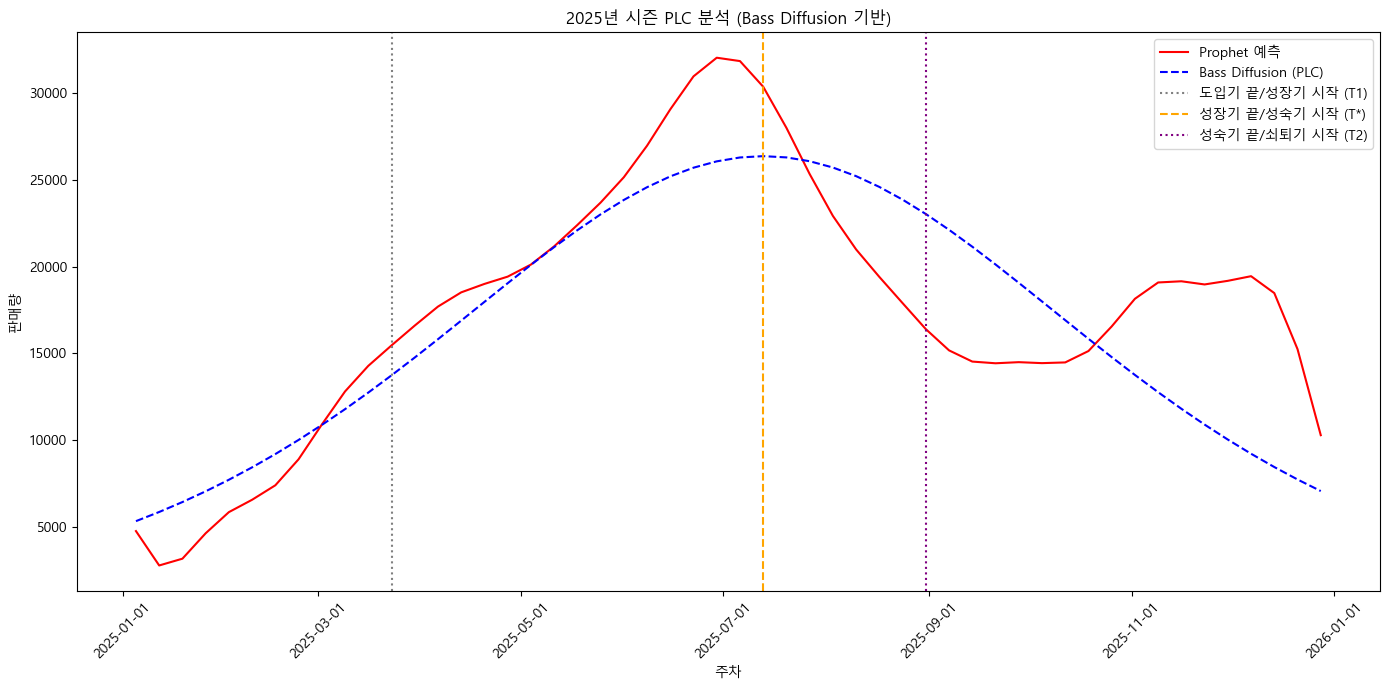

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 전환점 가져오기 (모든 행에 동일하므로 첫 행에서 추출)
T1_week = pd.to_datetime(final_df['T1_week'].iloc[0])
T_star_week = pd.to_datetime(final_df['T_star_week'].iloc[0])
T2_week = pd.to_datetime(final_df['T2_week'].iloc[0])

# 2. 시각화
plt.figure(figsize=(14, 7))

# Prophet 예측선
plt.plot(final_df['주차'], final_df['forecasted_sales'], label='Prophet 예측', color='red')

# Bass 곡선
plt.plot(final_df['주차'], final_df['bass_curve'], label='Bass Diffusion (PLC)', color='blue', linestyle='--')

# PLC 전환점 표시선
plt.axvline(T1_week, color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(T_star_week, color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(T2_week, color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')

# 기타 설정
plt.title('2025년 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.xticks(rotation=45)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()


## 봄 시즌

In [4]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 '봄' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '봄'].copy()

# 2. Prophet 학습용 데이터 준비 (봄 시즌 전체 판매수량 집계)
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 예측
m = Prophet(
    changepoint_prior_scale=0.2,
    changepoint_range=0.8,
    seasonality_prior_scale=4, #현실성 확보와 peak 발생 방지를 위해 하향 조정
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

future = pd.date_range(start='2025-01-05', end='2025-06-01', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0).astype(int)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산
T_star_idx = np.argmax(bass_curve)
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]
T2_idx = np.where(np.cumsum(bass_curve) >= np.sum(bass_curve) * 0.7)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 결과 데이터프레임 생성
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. '전체' 값 할당
plc_result['전체_시즌'] = '봄'
plc_result['제품'] = '제품전체(봄)'
plc_result['시즌'] = '봄'

# 9. T1, T*, T2 시점도 컬럼으로 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 최종 컬럼 순서 정리
df_봄 = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]

# 두 데이터프레임을 행 방향으로 병합
combined_df = pd.concat([final_df, df_봄], ignore_index=True)

15:27:13 - cmdstanpy - INFO - Chain [1] start processing
15:27:14 - cmdstanpy - INFO - Chain [1] done processing


## 여름 시즌

In [5]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 '여름' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '여름'].copy()

# 2. Prophet 학습용 데이터 준비 (여름 시즌 전체 판매수량 집계)
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 예측
m = Prophet(
    changepoint_prior_scale=1,
    changepoint_range=0.9,
    seasonality_prior_scale=20, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

future = pd.date_range(start='2025-01-05', end='2025-10-05', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0).astype(int)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산
T_star_idx = np.argmax(bass_curve)
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]
T2_idx = np.where(np.cumsum(bass_curve) >= np.sum(bass_curve) * 0.7)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 결과 데이터프레임 생성
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. '전체' 값 할당
plc_result['전체_시즌'] = '여름'
plc_result['제품'] = '제품전체(여름)'
plc_result['시즌'] = '여름'

# 9. T1, T*, T2 시점도 컬럼으로 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 최종 컬럼 순서 정리
df_여름 = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]

# 두 데이터프레임을 행 방향으로 병합
combined_df = pd.concat([combined_df, df_여름], ignore_index=True)
combined_df

15:27:14 - cmdstanpy - INFO - Chain [1] start processing
15:27:14 - cmdstanpy - INFO - Chain [1] done processing


,전체_시즌,제품,시즌,주차,forecasted_sales,bass_curve,plc_stage,T1_week,T_star_week,T2_week
0,전체,제품전체,NaN,2025-01-05,4755,5327.232503,도입기,2025-03-23,2025-07-13,2025-08-31
1,전체,제품전체,NaN,2025-01-12,2773,5855.339374,도입기,2025-03-23,2025-07-13,2025-08-31
2,전체,제품전체,NaN,2025-01-19,3164,6427.692059,도입기,2025-03-23,2025-07-13,2025-08-31
3,전체,제품전체,NaN,2025-01-26,4628,7046.235425,도입기,2025-03-23,2025-07-13,2025-08-31
4,전체,제품전체,NaN,2025-02-02,5847,7712.595451,도입기,2025-03-23,2025-07-13,2025-08-31
...,...,...,...,...,...,...,...,...,...,...
109,여름,제품전체(여름),여름,2025-09-07,5899,6860.649022,쇠퇴기,2025-04-20,2025-06-15,2025-07-13
110,여름,제품전체(여름),여름,2025-09-14,5517,5717.311634,쇠퇴기,2025-04-20,2025-06-15,2025-07-13
111,여름,제품전체(여름),여름,2025-09-21,5400,4739.627923,쇠퇴기,2025-04-20,2025-06-15,2025-07-13
112,여름,제품전체(여름),여름,2025-09-28,1449,3912.104283,쇠퇴기,2025-04-20,2025-06-15,2025-07-13


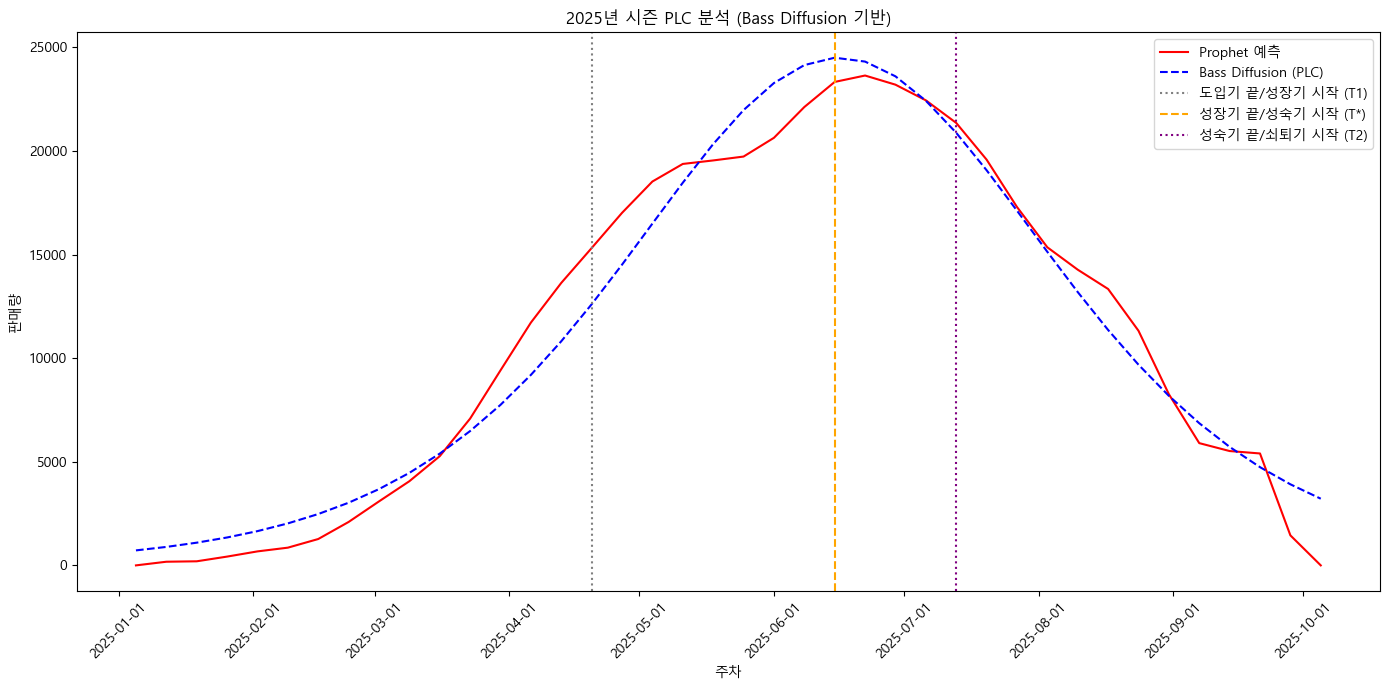

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 시각화
plt.figure(figsize=(14, 7))
check_df = combined_df[combined_df['전체_시즌']=='여름'].copy()

# Prophet 예측선
plt.plot(check_df['주차'], check_df['forecasted_sales'], label='Prophet 예측', color='red')

# Bass 곡선
plt.plot(check_df['주차'], check_df['bass_curve'], label='Bass Diffusion (PLC)', color='blue', linestyle='--')

# PLC 전환점 표시선
plt.axvline(T1_week, color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(T_star_week, color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(T2_week, color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')

# 기타 설정
plt.title('2025년 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.xticks(rotation=45)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()


## 가을 시즌

In [7]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 '가을' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '가을'].copy()

# 2. Prophet 학습용 데이터 준비 (가을 시즌 전체 판매수량 집계)
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 예측
m = Prophet(
    changepoint_prior_scale=0.8,
    changepoint_range=0.4,
    seasonality_prior_scale=10, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

future = pd.date_range(start='2025-01-05', end='2025-12-07', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0).astype(int)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산
T_star_idx = np.argmax(bass_curve)
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]
T2_idx = np.where(np.cumsum(bass_curve) >= np.sum(bass_curve) * 0.7)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 결과 데이터프레임 생성
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. '전체' 값 할당
plc_result['전체_시즌'] = '가을'
plc_result['제품'] = '제품전체(가을)'
plc_result['시즌'] = '가을'

# 9. T1, T*, T2 시점도 컬럼으로 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 최종 컬럼 순서 정리
df_가을 = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]

# 두 데이터프레임을 행 방향으로 병합
combined_df = pd.concat([combined_df, df_가을], ignore_index=True)
combined_df

15:27:14 - cmdstanpy - INFO - Chain [1] start processing
15:27:16 - cmdstanpy - INFO - Chain [1] done processing


,전체_시즌,제품,시즌,주차,forecasted_sales,bass_curve,plc_stage,T1_week,T_star_week,T2_week
0,전체,제품전체,NaN,2025-01-05,4755,5327.232503,도입기,2025-03-23,2025-07-13,2025-08-31
1,전체,제품전체,NaN,2025-01-12,2773,5855.339374,도입기,2025-03-23,2025-07-13,2025-08-31
2,전체,제품전체,NaN,2025-01-19,3164,6427.692059,도입기,2025-03-23,2025-07-13,2025-08-31
3,전체,제품전체,NaN,2025-01-26,4628,7046.235425,도입기,2025-03-23,2025-07-13,2025-08-31
4,전체,제품전체,NaN,2025-02-02,5847,7712.595451,도입기,2025-03-23,2025-07-13,2025-08-31
...,...,...,...,...,...,...,...,...,...,...
158,가을,제품전체(가을),가을,2025-11-09,2335,2687.911450,쇠퇴기,2025-08-10,2025-10-05,2025-10-19
159,가을,제품전체(가을),가을,2025-11-16,1820,2423.033828,쇠퇴기,2025-08-10,2025-10-05,2025-10-19
160,가을,제품전체(가을),가을,2025-11-23,1783,2153.454965,쇠퇴기,2025-08-10,2025-10-05,2025-10-19
161,가을,제품전체(가을),가을,2025-11-30,2548,1889.843518,쇠퇴기,2025-08-10,2025-10-05,2025-10-19


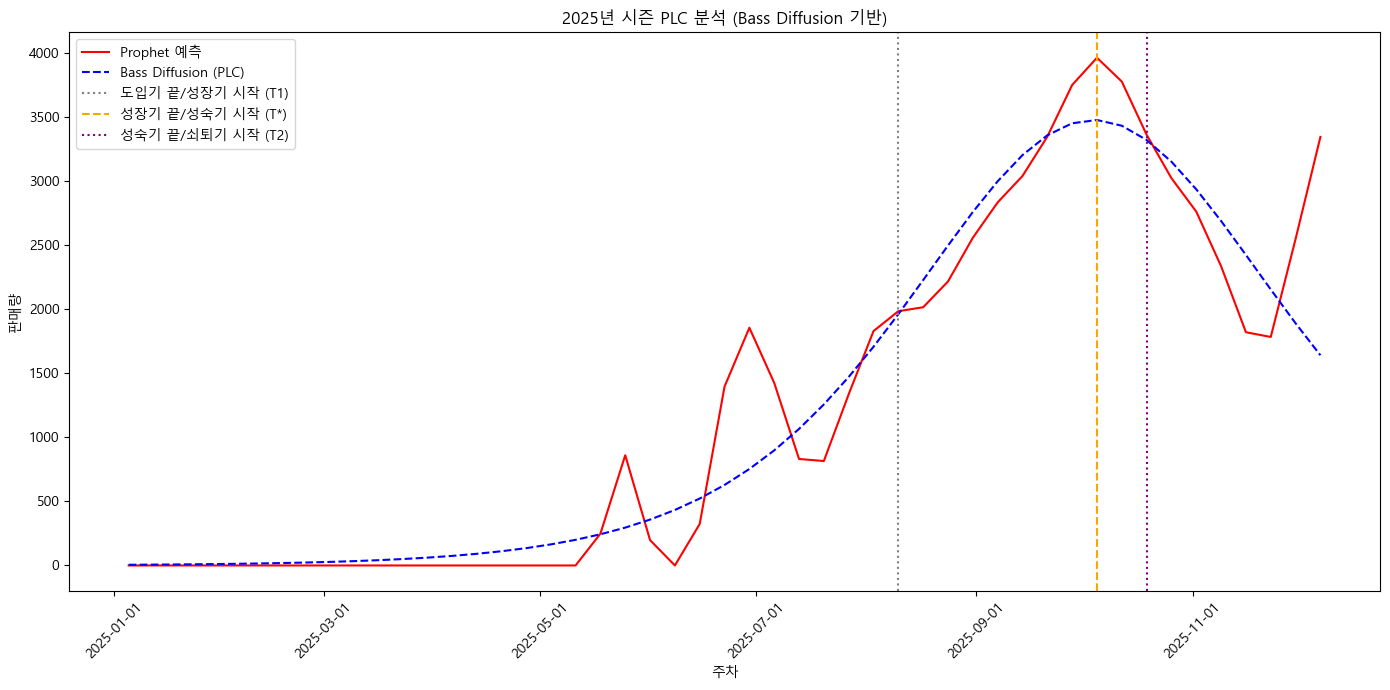

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 시각화
plt.figure(figsize=(14, 7))
check_df = combined_df[combined_df['전체_시즌']=='가을'].copy()

# Prophet 예측선
plt.plot(check_df['주차'], check_df['forecasted_sales'], label='Prophet 예측', color='red')

# Bass 곡선
plt.plot(check_df['주차'], check_df['bass_curve'], label='Bass Diffusion (PLC)', color='blue', linestyle='--')

# PLC 전환점 표시선
plt.axvline(T1_week, color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(T_star_week, color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(T2_week, color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')

# 기타 설정
plt.title('2025년 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.xticks(rotation=45)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()


## 겨울 시즌

In [9]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 '겨울' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '겨울'].copy()

# 2. Prophet 학습용 데이터 준비
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습
m = Prophet(
    changepoint_prior_scale=0.8,
    changepoint_range=0.3,
    seasonality_prior_scale=15, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

# 4. 미래 날짜 생성 및 예측 실행
future = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast_full = m.predict(future_df)
forecast_full['yhat'] = forecast_full['yhat'].clip(lower=0).astype(int)

# ✅ 5. 2025-06-01 이후만 필터링
forecast = forecast_full[forecast_full['ds'] >= pd.to_datetime('2025-06-01')].reset_index(drop=True)

# 6. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 7. PLC 전환점 계산
cumulative_bass = np.cumsum(bass_curve)
target_cumulative = cumulative_bass[-1] * 0.7
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]
T_star_idx = np.argmax(bass_curve[:T2_idx])
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 8. PLC 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 9. 결과 데이터프레임 생성
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. '전체' 값 할당
plc_result['전체_시즌'] = '겨울'
plc_result['제품'] = '제품전체(겨울)'
plc_result['시즌'] = '겨울'

# 9. T1, T*, T2 시점도 컬럼으로 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 최종 컬럼 순서 정리
df_겨울 = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]
# 06월 01일 이전 주차 제거
df_겨울 = df_겨울[df_겨울['주차'] >= pd.to_datetime('2025-06-01')].reset_index(drop=True)

# 12. combined_df에 병합
combined_df = pd.concat([combined_df, df_겨울], ignore_index=True)


15:27:17 - cmdstanpy - INFO - Chain [1] start processing
15:27:19 - cmdstanpy - INFO - Chain [1] done processing


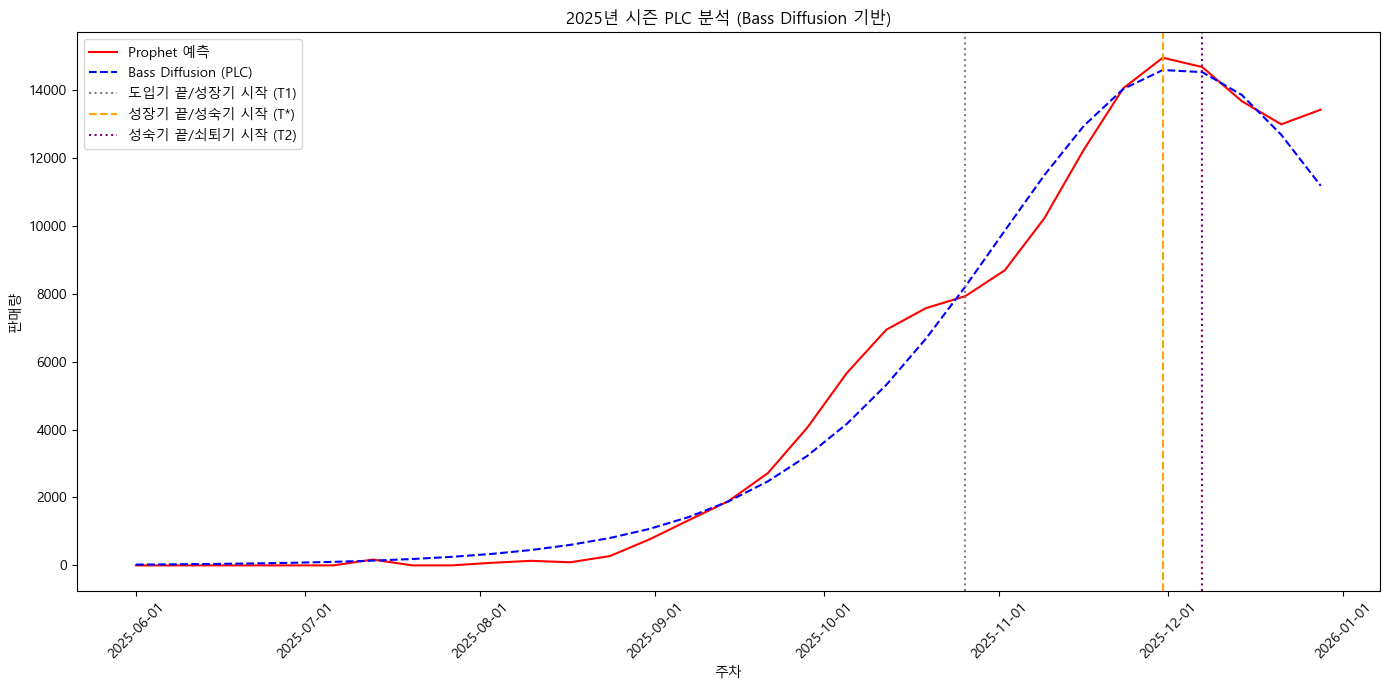

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 시각화
plt.figure(figsize=(14, 7))
check_df = combined_df[combined_df['전체_시즌']=='겨울'].copy()

# Prophet 예측선
plt.plot(check_df['주차'], check_df['forecasted_sales'], label='Prophet 예측', color='red')

# Bass 곡선
plt.plot(check_df['주차'], check_df['bass_curve'], label='Bass Diffusion (PLC)', color='blue', linestyle='--')

# PLC 전환점 표시선
plt.axvline(T1_week, color='gray', linestyle=':', label='도입기 끝/성장기 시작 (T1)')
plt.axvline(T_star_week, color='orange', linestyle='--', label='성장기 끝/성숙기 시작 (T*)')
plt.axvline(T2_week, color='purple', linestyle=':', label='성숙기 끝/쇠퇴기 시작 (T2)')

# 기타 설정
plt.title('2025년 시즌 PLC 분석 (Bass Diffusion 기반)')
plt.xlabel('주차')
plt.ylabel('판매량')
plt.xticks(rotation=45)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()


## 사계절 시즌

In [11]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 '사계절' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['시즌'] == '사계절'].copy()

# 2. Prophet 학습용 데이터 준비 (사계절 시즌 전체 판매수량 집계)
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 예측
m = Prophet(
    changepoint_prior_scale=0.05,
    changepoint_range=0.7,
    seasonality_prior_scale=10, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

future = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0).astype(int)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산
# 누적 Bass 판매량 기준으로 T2 계산
cumulative_bass = np.cumsum(bass_curve)
target_cumulative = cumulative_bass[-1] * 0.7
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]

# T*은 T2 이전 중 판매량이 가장 큰 지점
T_star_idx = np.argmax(bass_curve[:T2_idx])
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]


T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 결과 데이터프레임 생성
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. '전체' 값 할당
plc_result['전체_시즌'] = '사계절'
plc_result['제품'] = '제품전체(사계절)'
plc_result['시즌'] = '사계절'

# 9. T1, T*, T2 시점도 컬럼으로 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 최종 컬럼 순서 정리
df_사계절 = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]

# 두 데이터프레임을 행 방향으로 병합
combined_df = pd.concat([combined_df, df_사계절], ignore_index=True)
combined_df

15:27:19 - cmdstanpy - INFO - Chain [1] start processing
15:27:19 - cmdstanpy - INFO - Chain [1] done processing


,전체_시즌,제품,시즌,주차,forecasted_sales,bass_curve,plc_stage,T1_week,T_star_week,T2_week
0,전체,제품전체,NaN,2025-01-05,4755,5327.232503,도입기,2025-03-23,2025-07-13,2025-08-31
1,전체,제품전체,NaN,2025-01-12,2773,5855.339374,도입기,2025-03-23,2025-07-13,2025-08-31
2,전체,제품전체,NaN,2025-01-19,3164,6427.692059,도입기,2025-03-23,2025-07-13,2025-08-31
3,전체,제품전체,NaN,2025-01-26,4628,7046.235425,도입기,2025-03-23,2025-07-13,2025-08-31
4,전체,제품전체,NaN,2025-02-02,5847,7712.595451,도입기,2025-03-23,2025-07-13,2025-08-31
...,...,...,...,...,...,...,...,...,...,...
241,사계절,제품전체(사계절),사계절,2025-11-30,2190,3192.094737,쇠퇴기,2025-01-05,2025-05-04,2025-08-31
242,사계절,제품전체(사계절),사계절,2025-12-07,1901,3151.452239,쇠퇴기,2025-01-05,2025-05-04,2025-08-31
243,사계절,제품전체(사계절),사계절,2025-12-14,1734,3110.205124,쇠퇴기,2025-01-05,2025-05-04,2025-08-31
244,사계절,제품전체(사계절),사계절,2025-12-21,1729,3068.405346,쇠퇴기,2025-01-05,2025-05-04,2025-08-31


# 제품별

## 사계절_드레스셔츠

In [12]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 '사계절우븐셔츠' 시즌 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '사계절_우븐 셔츠_드레스셔츠_ZB'].copy()

# '카테고리' 컬럼명을 '제품'으로 변경
df = df.rename(columns={'카테고리': '제품'})

# 2. Prophet 학습용 데이터 준비 (사계절우븐셔츠 시즌 전체 판매수량 집계)
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 예측
m = Prophet(
    changepoint_prior_scale=0.6,
    changepoint_range=0.5,
    seasonality_prior_scale=100,
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

future = pd.date_range(start='2025-01-05', end='2025-12-28', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0).astype(int)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산
# 누적 Bass 판매량 기준으로 T2 계산
cumulative_bass = np.cumsum(bass_curve)
target_cumulative = cumulative_bass[-1] * 0.7
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]

# T*은 T2 이전 중 판매량이 가장 큰 지점
T_star_idx = np.argmax(bass_curve[:T2_idx])
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 결과 데이터프레임 생성
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. 제품, 시즌 값은 기존 df에서 대표값 추출하여 고정 입력
category_val = df['제품'].iloc[0]
season_val = df['시즌'].iloc[0]
plc_result['전체_시즌'] = np.nan
plc_result['제품'] = category_val
plc_result['시즌'] = season_val

# 9. T1, T*, T2 정보 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 컬럼 정리
df_사계절우븐셔츠 = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]

# 두 데이터프레임을 행 방향으로 병합
combined_df = pd.concat([combined_df, df_사계절우븐셔츠], ignore_index=True)
combined_df.sample(20)

15:27:20 - cmdstanpy - INFO - Chain [1] start processing
15:27:20 - cmdstanpy - INFO - Chain [1] done processing


,전체_시즌,제품,시즌,주차,forecasted_sales,bass_curve,plc_stage,T1_week,T_star_week,T2_week
228,사계절,제품전체(사계절),사계절,2025-08-31,3974,3641.657563,쇠퇴기,2025-01-05,2025-05-04,2025-08-31
213,사계절,제품전체(사계절),사계절,2025-05-18,3278,3884.647843,성숙기,2025-01-05,2025-05-04,2025-08-31
208,사계절,제품전체(사계절),사계절,2025-04-13,4791,3882.765266,성장기,2025-01-05,2025-05-04,2025-08-31
51,전체,제품전체,NaN,2025-12-28,10281,7061.732366,쇠퇴기,2025-03-23,2025-07-13,2025-08-31
56,봄,제품전체(봄),봄,2025-02-02,3999,4292.161083,도입기,2025-02-09,2025-03-09,2025-03-30
117,가을,제품전체(가을),가을,2025-01-26,0,9.941583,도입기,2025-08-10,2025-10-05,2025-10-19
148,가을,제품전체(가을),가을,2025-08-31,2557,2757.852517,성장기,2025-08-10,2025-10-05,2025-10-19
247,NaN,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-01-12,2815,3478.114009,성장기,2025-01-05,2025-07-20,2025-09-14
190,겨울,제품전체(겨울),겨울,2025-12-07,14679,14530.227621,쇠퇴기,2025-10-26,2025-11-30,2025-12-07
23,전체,제품전체,NaN,2025-06-15,29060,25197.064423,성장기,2025-03-23,2025-07-13,2025-08-31


## 겨울_일반팬츠

In [13]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 '겨울일반팬츠' 제품 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '겨울_팬츠_팬츠(일반)_ZB'].copy()
# '카테고리' 컬럼명을 '제품'으로 변경
df = df.rename(columns={'카테고리': '제품'})

# 2. Prophet 학습용 데이터 준비 (겨울일반팬츠 제품 전체 판매수량 집계)
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 예측
m = Prophet(
    changepoint_prior_scale=0.5,
    changepoint_range=0.5,
    seasonality_prior_scale=100, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

future = pd.date_range(start='2025-06-01', end='2025-12-28', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0).astype(int)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산
# 누적 Bass 판매량 기준으로 T2 계산
cumulative_bass = np.cumsum(bass_curve)
target_cumulative = cumulative_bass[-1] * 0.7
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]

# T*은 T2 이전 중 판매량이 가장 큰 지점
T_star_idx = np.argmax(bass_curve[:T2_idx])
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 결과 데이터프레임 생성
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. 제품, 시즌 값은 기존 df에서 대표값 추출하여 고정 입력
category_val = df['제품'].iloc[0]
season_val = df['시즌'].iloc[0]
plc_result['전체_시즌'] = np.nan
plc_result['제품'] = category_val
plc_result['시즌'] = season_val

# 9. T1, T*, T2 정보 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 컬럼 정리
df_겨울일반팬츠 = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]
# 06월 01일 이전 주차 제거
df_겨울일반팬츠 = df_겨울일반팬츠[df_겨울일반팬츠['주차'] >= pd.to_datetime('2025-06-01')].reset_index(drop=True)

# 두 데이터프레임을 행 방향으로 병합
combined_df = pd.concat([combined_df, df_겨울일반팬츠], ignore_index=True)

15:27:20 - cmdstanpy - INFO - Chain [1] start processing
15:27:21 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
combined_df[combined_df['제품']=='겨울_팬츠_팬츠(일반)_ZB']

,전체_시즌,제품,시즌,주차,forecasted_sales,bass_curve,plc_stage,T1_week,T_star_week,T2_week
298,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-06-01,0,1.817495,도입기,2025-10-26,2025-11-30,2025-12-07
299,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-06-08,0,2.556597,도입기,2025-10-26,2025-11-30,2025-12-07
300,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-06-15,0,3.596099,도입기,2025-10-26,2025-11-30,2025-12-07
301,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-06-22,0,5.057938,도입기,2025-10-26,2025-11-30,2025-12-07
302,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-06-29,0,7.113388,도입기,2025-10-26,2025-11-30,2025-12-07
303,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-07-06,0,10.002876,도입기,2025-10-26,2025-11-30,2025-12-07
304,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-07-13,0,14.063597,도입기,2025-10-26,2025-11-30,2025-12-07
305,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-07-20,0,19.767873,도입기,2025-10-26,2025-11-30,2025-12-07
306,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-07-27,0,27.776127,도입기,2025-10-26,2025-11-30,2025-12-07
307,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-08-03,0,39.009480,도입기,2025-10-26,2025-11-30,2025-12-07


## 겨울_패딩사파리

In [15]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 '겨울패딩사파리' 제품 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '겨울_사파리_패딩사파리_ZB'].copy()
# '카테고리' 컬럼명을 '제품'으로 변경
df = df.rename(columns={'카테고리': '제품'})

# 2. Prophet 학습용 데이터 준비 (겨울패딩사파리 제품 전체 판매수량 집계)
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 예측
m = Prophet(
    changepoint_prior_scale=0.6,
    changepoint_range=0.6,
    seasonality_prior_scale=50, 
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

future = pd.date_range(start='2025-06-01', end='2025-12-28', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0).astype(int)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산
# 누적 Bass 판매량 기준으로 T2 계산
cumulative_bass = np.cumsum(bass_curve)
target_cumulative = cumulative_bass[-1] * 0.7
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]

# T*은 T2 이전 중 판매량이 가장 큰 지점
T_star_idx = np.argmax(bass_curve[:T2_idx])
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 결과 데이터프레임 생성
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. 제품, 시즌 값은 기존 df에서 대표값 추출하여 고정 입력
category_val = df['제품'].iloc[0]
season_val = df['시즌'].iloc[0]
plc_result['전체_시즌'] = np.nan
plc_result['제품'] = category_val
plc_result['시즌'] = season_val

# 9. T1, T*, T2 정보 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 컬럼 정리
df_겨울패딩사파리 = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]
# 06월 01일 이전 주차 제거
df_겨울패딩사파리 = df_겨울패딩사파리[df_겨울패딩사파리['주차'] >= pd.to_datetime('2025-06-01')].reset_index(drop=True)

# 두 데이터프레임을 행 방향으로 병합
combined_df = pd.concat([combined_df, df_겨울패딩사파리], ignore_index=True)
combined_df

15:27:21 - cmdstanpy - INFO - Chain [1] start processing
15:27:22 - cmdstanpy - INFO - Chain [1] done processing


,전체_시즌,제품,시즌,주차,forecasted_sales,bass_curve,plc_stage,T1_week,T_star_week,T2_week
0,전체,제품전체,NaN,2025-01-05,4755,5327.232503,도입기,2025-03-23,2025-07-13,2025-08-31
1,전체,제품전체,NaN,2025-01-12,2773,5855.339374,도입기,2025-03-23,2025-07-13,2025-08-31
2,전체,제품전체,NaN,2025-01-19,3164,6427.692059,도입기,2025-03-23,2025-07-13,2025-08-31
3,전체,제품전체,NaN,2025-01-26,4628,7046.235425,도입기,2025-03-23,2025-07-13,2025-08-31
4,전체,제품전체,NaN,2025-02-02,5847,7712.595451,도입기,2025-03-23,2025-07-13,2025-08-31
...,...,...,...,...,...,...,...,...,...,...
355,NaN,겨울_사파리_패딩사파리_ZB,겨울,2025-11-30,2120,2145.546385,성숙기,2025-11-16,2025-11-30,2025-12-07
356,NaN,겨울_사파리_패딩사파리_ZB,겨울,2025-12-07,1999,1962.606338,쇠퇴기,2025-11-16,2025-11-30,2025-12-07
357,NaN,겨울_사파리_패딩사파리_ZB,겨울,2025-12-14,1940,1439.860227,쇠퇴기,2025-11-16,2025-11-30,2025-12-07
358,NaN,겨울_사파리_패딩사파리_ZB,겨울,2025-12-21,2248,894.386465,쇠퇴기,2025-11-16,2025-11-30,2025-12-07


## 여름_캐주얼셔츠

In [16]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 '여름캐주얼셔츠' 제품 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '여름_우븐 셔츠_캐쥬얼셔츠_ZB'].copy()
# '카테고리' 컬럼명을 '제품'으로 변경
df = df.rename(columns={'카테고리': '제품'})

# 2. Prophet 학습용 데이터 준비 (여름캐주얼셔츠 제품 전체 판매수량 집계)
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 예측
m = Prophet(
    changepoint_prior_scale=0.05,
    changepoint_range=0.9,
    seasonality_prior_scale=100,
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(final_train)

future = pd.date_range(start='2025-01-05', end='2025-10-05', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0).astype(int)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산
# 누적 Bass 판매량 기준으로 T2 계산
cumulative_bass = np.cumsum(bass_curve)
target_cumulative = cumulative_bass[-1] * 0.7
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]

# T*은 T2 이전 중 판매량이 가장 큰 지점
T_star_idx = np.argmax(bass_curve[:T2_idx])
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 결과 데이터프레임 생성
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. 제품, 시즌 값은 기존 df에서 대표값 추출하여 고정 입력
category_val = df['제품'].iloc[0]
season_val = df['시즌'].iloc[0]
plc_result['전체_시즌'] = np.nan
plc_result['제품'] = category_val
plc_result['시즌'] = season_val

# 9. T1, T*, T2 정보 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 컬럼 정리
df_여름캐주얼셔츠 = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]

# 두 데이터프레임을 행 방향으로 병합
combined_df = pd.concat([combined_df, df_여름캐주얼셔츠], ignore_index=True)
combined_df.sample(20)

15:27:22 - cmdstanpy - INFO - Chain [1] start processing
15:27:22 - cmdstanpy - INFO - Chain [1] done processing


,전체_시즌,제품,시즌,주차,forecasted_sales,bass_curve,plc_stage,T1_week,T_star_week,T2_week
399,NaN,여름_우븐 셔츠_캐쥬얼셔츠_ZB,여름,2025-10-05,322,309.256621,쇠퇴기,2025-05-11,2025-06-29,2025-07-27
308,NaN,겨울_팬츠_팬츠(일반)_ZB,겨울,2025-08-10,5,54.748110,도입기,2025-10-26,2025-11-30,2025-12-07
46,전체,제품전체,NaN,2025-11-23,18969,10892.510272,쇠퇴기,2025-03-23,2025-07-13,2025-08-31
367,NaN,여름_우븐 셔츠_캐쥬얼셔츠_ZB,여름,2025-02-23,43,123.363087,도입기,2025-05-11,2025-06-29,2025-07-27
113,여름,제품전체(여름),여름,2025-10-05,0,3217.504200,쇠퇴기,2025-04-20,2025-06-15,2025-07-13
256,NaN,사계절_우븐 셔츠_드레스셔츠_ZB,사계절,2025-03-16,3765,3616.812785,성장기,2025-01-05,2025-07-20,2025-09-14
381,NaN,여름_우븐 셔츠_캐쥬얼셔츠_ZB,여름,2025-06-01,1252,1393.987171,성장기,2025-05-11,2025-06-29,2025-07-27
39,전체,제품전체,NaN,2025-10-05,14434,17989.753240,쇠퇴기,2025-03-23,2025-07-13,2025-08-31
235,사계절,제품전체(사계절),사계절,2025-10-19,4388,3420.310992,쇠퇴기,2025-01-05,2025-05-04,2025-08-31
201,사계절,제품전체(사계절),사계절,2025-02-23,4300,3808.537826,성장기,2025-01-05,2025-05-04,2025-08-31


## 봄_싱글코트

In [17]:
import numpy as np
import pandas as pd
from prophet import Prophet
from scipy.optimize import curve_fit

# 1. 데이터 불러오기 및 '봄싱글코트' 제품 필터링
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')
df['주차'] = pd.to_datetime(df['주차'])
df = df[df['카테고리'] == '봄_코트_싱글코트_ZB'].copy()
# '카테고리' 컬럼명을 '제품'으로 변경
df = df.rename(columns={'카테고리': '제품'})

# 2. Prophet 학습용 데이터 준비 (봄싱글코트 제품 전체 판매수량 집계)
df_prophet = df.groupby('주차', as_index=False)['판매수량'].sum()
df_prophet = df_prophet.rename(columns={'주차': 'ds', '판매수량': 'y'})
final_train = df_prophet[(df_prophet['ds'].dt.year >= 2021) & (df_prophet['ds'].dt.year <= 2024)]

# 3. Prophet 모델 학습 및 2025년 예측
m = Prophet(
    changepoint_prior_scale=0.0001,
    changepoint_range=1.0,
    seasonality_prior_scale=900,
    yearly_seasonality=True,
    seasonality_mode='additive'
)
m.fit(final_train)

future = pd.date_range(start='2025-01-05', end='2025-06-01', freq='W-SUN')
future_df = pd.DataFrame({'ds': future})
forecast = m.predict(future_df)
forecast['yhat'] = forecast['yhat'].clip(lower=0).astype(int)

# 4. Bass 모델 적합
forecast['smoothed'] = forecast['yhat'].rolling(window=3, center=True, min_periods=1).mean()
sales_array = forecast['smoothed'].values
time = np.arange(1, len(sales_array) + 1)

def bass_cumulative(t, p, q, m):
    return m * (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

params, _ = curve_fit(bass_cumulative, time, np.cumsum(sales_array),
                      p0=[0.01, 0.1, np.cumsum(sales_array).max()],
                      bounds=(0, [1, 1, 1e7]))
p, q, m_val = params
bass_cum = bass_cumulative(time, p, q, m_val)
bass_curve = np.diff(np.insert(bass_cum, 0, 0))

# 5. PLC 전환점 계산
# 누적 Bass 판매량 기준으로 T2 계산
cumulative_bass = np.cumsum(bass_curve)
target_cumulative = cumulative_bass[-1] * 0.7
T2_idx = np.where(cumulative_bass >= target_cumulative)[0][0]

# T*은 T2 이전 중 판매량이 가장 큰 지점
T_star_idx = np.argmax(bass_curve[:T2_idx])
half_peak = bass_curve[T_star_idx] / 2
T1_idx = np.where(bass_curve >= half_peak)[0][0]

T1_week = forecast['ds'].iloc[T1_idx]
T_star_week = forecast['ds'].iloc[T_star_idx]
T2_week = forecast['ds'].iloc[T2_idx]

# 6. PLC 구간 라벨링
plc_labels = []
for i in range(len(forecast)):
    if i < T1_idx:
        plc_labels.append('도입기')
    elif i < T_star_idx:
        plc_labels.append('성장기')
    elif i < T2_idx:
        plc_labels.append('성숙기')
    else:
        plc_labels.append('쇠퇴기')

# 7. 결과 데이터프레임 생성
plc_result = pd.DataFrame({
    '주차': forecast['ds'],
    'forecasted_sales': forecast['yhat'],
    'bass_curve': bass_curve,
    'plc_stage': plc_labels
})

# 8. 제품, 시즌 값은 기존 df에서 대표값 추출하여 고정 입력
category_val = df['제품'].iloc[0]
season_val = df['시즌'].iloc[0]
plc_result['전체_시즌'] = np.nan
plc_result['제품'] = category_val
plc_result['시즌'] = season_val

# 9. T1, T*, T2 정보 추가
plc_result['T1_week'] = T1_week
plc_result['T_star_week'] = T_star_week
plc_result['T2_week'] = T2_week

# 10. 컬럼 정리
df_봄싱글코트 = plc_result[['전체_시즌', '제품', '시즌', '주차', 'forecasted_sales', 'bass_curve', 'plc_stage',
                       'T1_week', 'T_star_week', 'T2_week']]

# 두 데이터프레임을 행 방향으로 병합
combined_df = pd.concat([combined_df, df_봄싱글코트], ignore_index=True)

15:27:22 - cmdstanpy - INFO - Chain [1] start processing
15:27:23 - cmdstanpy - INFO - Chain [1] done processing


# 최종 확인

In [ ]:
# 전체 행/열 안 잘리게 보기
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', None)

display(combined_df)

,전체_시즌,제품,시즌,주차,forecasted_sales,bass_curve,plc_stage,T1_week,T_star_week,T2_week
0,전체,제품전체,NaN,2025-01-05,4755,5327.232503,도입기,2025-03-23,2025-07-13,2025-08-31
1,전체,제품전체,NaN,2025-01-12,2773,5855.339374,도입기,2025-03-23,2025-07-13,2025-08-31
2,전체,제품전체,NaN,2025-01-19,3164,6427.692059,도입기,2025-03-23,2025-07-13,2025-08-31
3,전체,제품전체,NaN,2025-01-26,4628,7046.235425,도입기,2025-03-23,2025-07-13,2025-08-31
4,전체,제품전체,NaN,2025-02-02,5847,7712.595451,도입기,2025-03-23,2025-07-13,2025-08-31
5,전체,제품전체,NaN,2025-02-09,6560,8427.970941,도입기,2025-03-23,2025-07-13,2025-08-31
6,전체,제품전체,NaN,2025-02-16,7394,9193.010880,도입기,2025-03-23,2025-07-13,2025-08-31
7,전체,제품전체,NaN,2025-02-23,8893,10007.678633,도입기,2025-03-23,2025-07-13,2025-08-31
8,전체,제품전체,NaN,2025-03-02,10893,10871.105331,도입기,2025-03-23,2025-07-13,2025-08-31
9,전체,제품전체,NaN,2025-03-09,12802,11781.436293,도입기,2025-03-23,2025-07-13,2025-08-31


# 빈 제품 데이터 채워넣고 정렬

In [19]:
import pandas as pd

# 1. combined_df의 제품 목록
existing_products = combined_df['제품'].unique()

# 2. 원본 데이터 불러오기
df = pd.read_csv('./data/model_df_할인율NaN&음수처리.csv')

# 3. '카테고리' 컬럼 기준으로 필터링 (combined_df에 없는 제품만)
unseen_df = df[~df['카테고리'].isin(existing_products)].copy()

# 4. 카테고리 & 시즌 조합에서 중복 제거 (대표 1줄씩)
unique_combinations = unseen_df[['카테고리', '시즌']].drop_duplicates().reset_index(drop=True)

# 5. 빈 데이터프레임 만들기 (combined_df와 같은 컬럼 구조)
placeholder_df = pd.DataFrame(columns=combined_df.columns)

# 6. 제품 & 시즌 값만 채워 넣기
placeholder_df['제품'] = unique_combinations['카테고리']
placeholder_df['시즌'] = unique_combinations['시즌']

# 7. combined_df와 합치기
final_combined_df = pd.concat([combined_df, placeholder_df], ignore_index=True)

C:\Users\kjh27\AppData\Local\Temp\ipykernel_29560\227860284.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_combined_df = pd.concat([combined_df, placeholder_df], ignore_index=True)


In [20]:
# 예측 수치형 컬럼 NaN → 0 처리
final_combined_df['forecasted_sales'] = final_combined_df['forecasted_sales'].fillna(0)
final_combined_df['bass_curve'] = final_combined_df['bass_curve'].fillna(0)
final_combined_df['plc_stage'] = final_combined_df['plc_stage'].fillna(0)
final_combined_df['T1_week'] = final_combined_df['T1_week'].fillna('2025-01-05')
final_combined_df['T_star_week'] = final_combined_df['T_star_week'].fillna('2025-01-05')
final_combined_df['T2_week'] = final_combined_df['T2_week'].fillna('2025-01-05')

# 사용자 정의 시즌 순서 + NaN 우선 처리
season_order = ['봄', '여름', '가을', '겨울', '사계절']
final_combined_df['시즌'] = pd.Categorical(final_combined_df['시즌'], categories=season_order, ordered=True)

# '제품전체' 여부
final_combined_df['is_total_product'] = final_combined_df['제품'].astype(str).str.startswith('제품전체')

# 시즌이 NaN인지 여부
final_combined_df['is_season_nan'] = final_combined_df['시즌'].isna()

# 정렬 실행: 시즌 NaN → 시즌 순서 → 제품전체 우선 → 제품명 → 주차
final_combined_df = final_combined_df.sort_values(
    by=['is_season_nan', '시즌', 'is_total_product', '제품', '주차'],
    ascending=[False, True, False, True, True]
).reset_index(drop=True)

# 정렬용 컬럼 제거
final_combined_df.drop(columns=['is_total_product', 'is_season_nan'], inplace=True)


C:\Users\kjh27\AppData\Local\Temp\ipykernel_29560\946931506.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_combined_df['forecasted_sales'] = final_combined_df['forecasted_sales'].fillna(0)


# CSV 출력

In [ ]:
# final_combined_df.to_csv("수요예측기반_입고량계획.csv", index=False, encoding="utf-8-sig")